Columns: ['month', 'category', 'net_inflow_crore']


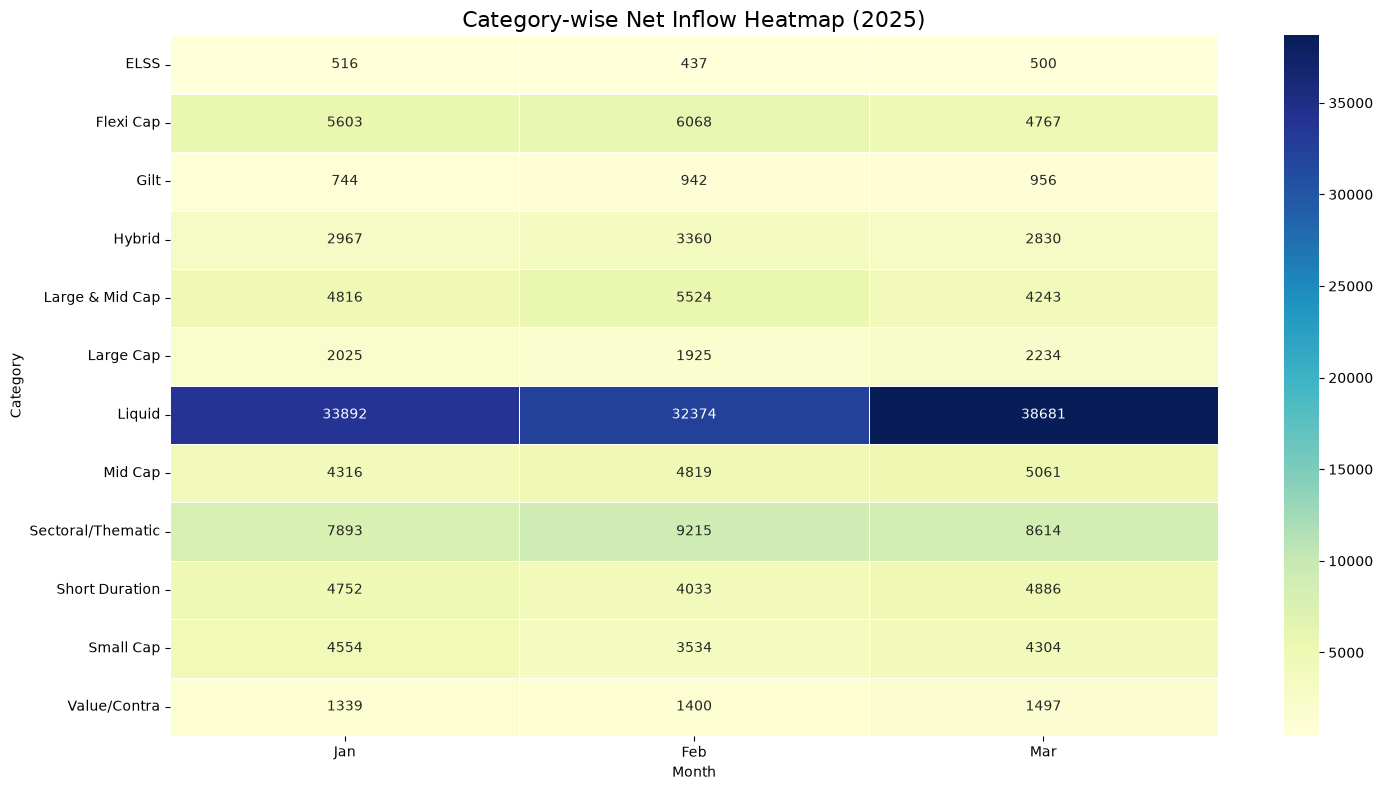

Category heatmap created successfully.
Saved to: Reports/Category_Heatmap.png


In [ ]:

# DAY 3 - TASK 4: CATEGORY-WISE INFLOW HEATMAP

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Loading category inflow data:
df = pd.read_csv("../Data/Raw/05_category_inflows.csv")

# Clean column names:
df.columns = (
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
)

print("Columns:", df.columns.tolist())

# Detecting columns:
month_col = next(col for col in df.columns if "month" in col or "date" in col)
category_col = next(col for col in df.columns if "categor" in col)
inflow_col = next(
    col for col in df.columns
    if "net" in col and "inflow" in col
)

# Creating month labels:
df[month_col] = pd.to_datetime(df[month_col])
df["month_name"] = df[month_col].dt.strftime("%b")
df["month_order"] = df[month_col].dt.month

# Keep the latest available year:
latest_year = df[month_col].dt.year.max()
df = df[df[month_col].dt.year == latest_year].copy()

# Create heatmap table:
heatmap_data = df.pivot_table(
    index=category_col,
    columns="month_name",
    values=inflow_col,
    aggfunc="sum"
)

# Arrange months chronologically:
month_order = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

heatmap_data = heatmap_data.reindex(
    columns=[m for m in month_order if m in heatmap_data.columns]
)

# Create heatmap:
plt.figure(figsize=(15, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title(
    f"Category-wise Net Inflow Heatmap ({latest_year})",
    fontsize=16
)
plt.xlabel("Month")
plt.ylabel("Category")

plt.tight_layout()

# Save chart:
plt.savefig(
    "../Reports/Category_Heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Category heatmap created successfully.")
print("Saved to: Reports/Category_Heatmap.png")